<a href="https://colab.research.google.com/github/meghna-panda/ElevateLabs-task6/blob/main/t6_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving Iris.csv to Iris.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap

# Load dataset
df = pd.read_csv("Iris.csv")
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Drop ID column if present
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

# Encode species labels
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Use first two features for visualization (or all for better accuracy)
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Labels

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


K = 1
Accuracy: 0.9777777777777777


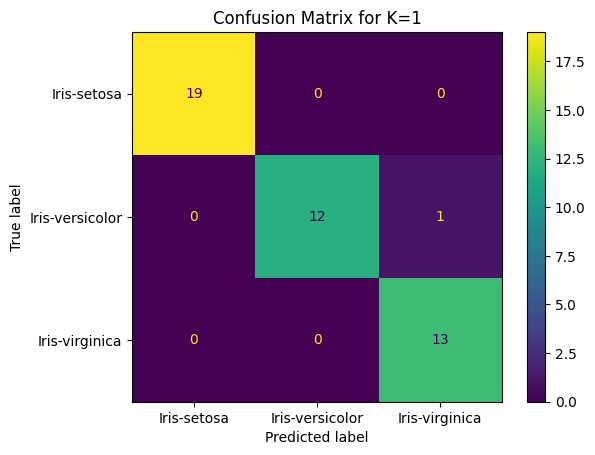

K = 3
Accuracy: 1.0


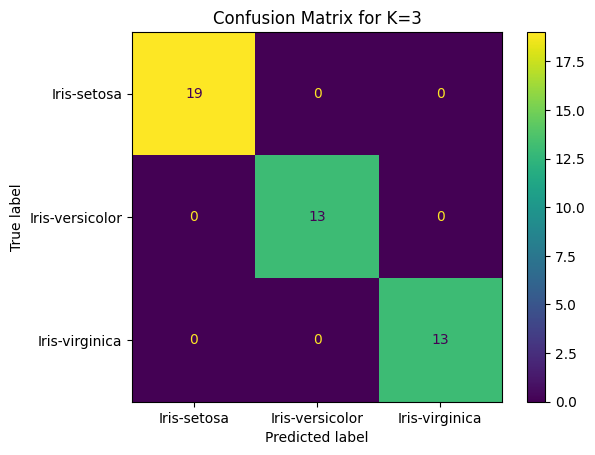

K = 5
Accuracy: 1.0


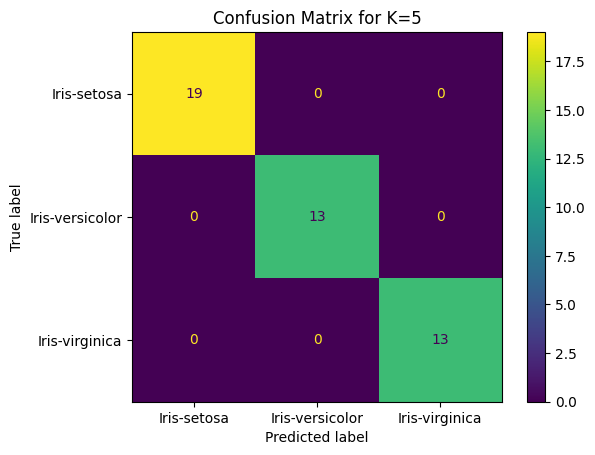

K = 7
Accuracy: 1.0


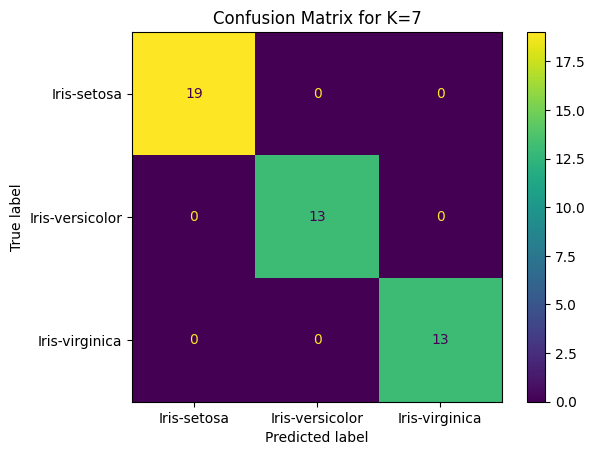

K = 9
Accuracy: 1.0


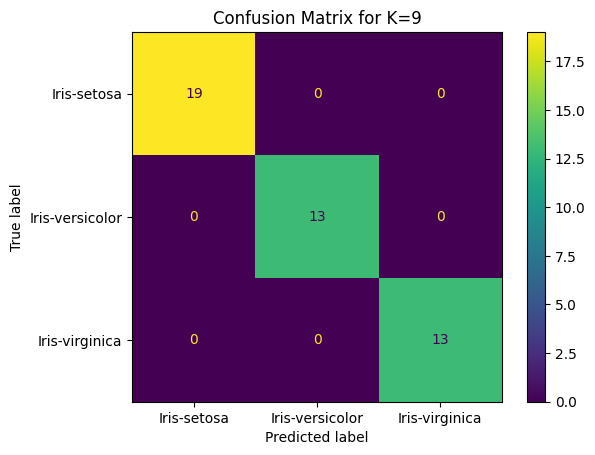

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

k_values = [1, 3, 5, 7, 9]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    print(f"K = {k}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()
    plt.title(f"Confusion Matrix for K={k}")
    plt.show()


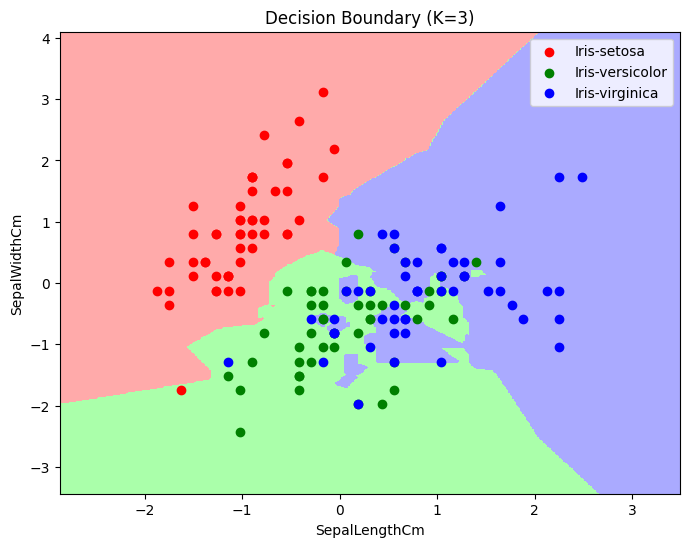

In [5]:
def plot_decision_boundary(X, y, model, title):
    h = .02
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)
    for idx, color in enumerate(cmap_bold):
        plt.scatter(X[y == idx, 0], X[y == idx, 1], c=color, label=le.classes_[idx])

    plt.legend()
    plt.title(title)
    plt.xlabel(df.columns[0])
    plt.ylabel(df.columns[1])
    plt.show()

# Train with K=3 and visualize
knn_best = KNeighborsClassifier(n_neighbors=3)
knn_best.fit(X_train[:, :2], y_train)  # Only first 2 features for plotting
plot_decision_boundary(X_scaled[:, :2], y, knn_best, "Decision Boundary (K=3)")
